In [1]:
!pip install -q transformers accelerate bitsandbytes langgraph langchain-huggingface langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 16.9 MB/s eta 0:00:00


In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from transformers import pipeline
from pydantic import BaseModel, Field
import operator

In [3]:
from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

text_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-7B-Instruct",
    model_kwargs={"quantization_config": bnb_config},
    device_map="auto",
    max_new_tokens=150,
    do_sample=True,
    temperature=0.8,
    return_full_text=False,
)

local_llm = HuggingFacePipeline(pipeline=text_pipeline)
model = ChatHuggingFace(llm=local_llm)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [4]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [5]:
# with_structured_output relies on the PROVIDER's native structured-output API
# (tool calling / json_schema) -- a raw local HuggingFacePipeline doesn't expose
# that. PydanticOutputParser is the portable, prompt+parse alternative: it
# WORKS ON ANY MODEL because it just asks the model to emit JSON in its reply,
# then parses that text -- exactly why you learned it as the universal fallback
# earlier in this repo.
eval_parser = PydanticOutputParser(pydantic_object=TweetEvaluation)

In [6]:
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [7]:
def generate_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = model.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [8]:
import json
import re

def evaluate_tweet(state: TweetState):

    # Skip eval_parser.get_format_instructions() entirely -- its default
    # template includes a generic "foo" example that small models latch onto
    # and echo back verbatim instead of following. Write the instruction
    # ourselves, with ONLY the real schema and a REAL filled example.
    prompt_text = f"""You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format.

Tweet to evaluate: "{state['tweet']}"

Criteria:
1. Originality – Is this fresh, or overused?
2. Humor – Does it genuinely land?
3. Punchiness – Short, sharp, scroll-stopping?
4. Virality Potential – Shareable?
5. Format – Not Q&A style, not a setup-punchline joke, under 280 characters?

Auto-reject if it's Q&A format, over 280 characters, a setup-punchline joke, or ends with a weak generic line.

Respond with EXACTLY one JSON object and NOTHING else -- no explanation, no schema, no markdown fences.
The JSON must have exactly these two keys: "evaluation" and "feedback".
"evaluation" must be the exact string "approved" or the exact string "needs_improvement".
"feedback" must be a string with your one-paragraph critique.

Example of the ONLY acceptable response format:
{{"evaluation": "needs_improvement", "feedback": "The joke relies on a tired setup and the ending line undercuts the humor."}}

Now write your real evaluation of the tweet above, in that exact format:
"""

    raw_response = model.invoke([HumanMessage(content=prompt_text)]).content

    # Extract just the {...} block, in case the model adds any stray text around it
    match = re.search(r'\{.*?"evaluation".*?\}', raw_response, re.DOTALL)
    if not match:
        raise ValueError(f"Could not find a JSON object in model output: {raw_response}")

    data = json.loads(match.group())

    # Guard against a malformed/hallucinated evaluation value
    if data.get('evaluation') not in ('approved', 'needs_improvement'):
        data['evaluation'] = 'needs_improvement'   # safe default -- keeps the loop going rather than crashing

    parsed = TweetEvaluation(**data)   # validates through Pydantic directly, no PydanticOutputParser needed

    return {'evaluation': parsed.evaluation, 'feedback': parsed.feedback, 'feedback_history': [parsed.feedback]}

In [9]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [10]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

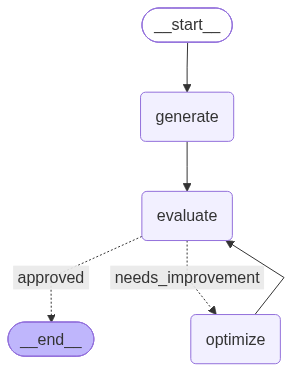

In [11]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
workflow

In [12]:
initial_state = {
    "topic": "when your wifi disconnects during an online exam",
    "iteration": 1,
    "max_iteration": 2   # lower than before -- local inference is much slower per call than a hosted API
}
result = workflow.invoke(initial_state)

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_len

In [13]:
result

{'topic': 'when your wifi disconnects during an online exam',
 'tweet': 'When your WiFi takes a break mid-exam, you realize maybe coffee shops were onto something. #WiFiFail #OnlineExamLife',
 'evaluation': 'approved',
 'feedback': 'Fresh and relatable content that hits multiple pain points of online exam takers, effectively using hashtags for trendability. The tone is genuine and the message lands well.',
 'iteration': 2,
 'max_iteration': 2,
 'tweet_history': ['When your WiFi decides to take a nap mid-exam, it\'s like nature\'s way of saying, "Hey, maybe studying in a coffee shop was a good idea after all." #WiFiFail #OnlineExamLife',
  'When your WiFi takes a break mid-exam, you realize maybe coffee shops were onto something. #WiFiFail #OnlineExamLife'],
 'feedback_history': ['While the tweet attempts to blend a relatable scenario with humor, it leans into a common trope of WiFi failures and the ending line feels slightly forced, potentially diminishing its impact.',
  'Fresh and re

In [14]:
for tweet in result['tweet_history']:
    print(tweet)
    print('---')

When your WiFi decides to take a nap mid-exam, it's like nature's way of saying, "Hey, maybe studying in a coffee shop was a good idea after all." #WiFiFail #OnlineExamLife
---
When your WiFi takes a break mid-exam, you realize maybe coffee shops were onto something. #WiFiFail #OnlineExamLife
---
